In [3]:
!pip install pandas matplotlib seaborn textblob

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

In [4]:
reviews = {

    "Review": [

        "This book was absolutely amazing and inspiring",

        "I loved the storytelling and the characters",

        "The writing style was beautiful and engaging",

        "One of the best books I have ever read",

        "Fantastic plot and excellent ending",

        "The book was decent but a little slow",

        "It was okay, not great but not terrible",

        "Average story with predictable events",

        "The book became boring in the middle",

        "I did not enjoy the writing style",

        "Very disappointing and poorly written",

        "Terrible ending and weak character development",

        "Absolutely wonderful reading experience",

        "Highly recommended for book lovers",

        "The story was emotional and very well written"

    ]
}

df = pd.DataFrame(reviews)

print(df.head())

                                           Review
0  This book was absolutely amazing and inspiring
1     I loved the storytelling and the characters
2    The writing style was beautiful and engaging
3          One of the best books I have ever read
4             Fantastic plot and excellent ending


In [5]:
def analyze_sentiment(text):

    analysis = TextBlob(text)

    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [6]:
df["Sentiment"] = df["Review"].apply(analyze_sentiment)

print(df)

                                            Review Sentiment
0   This book was absolutely amazing and inspiring  Positive
1      I loved the storytelling and the characters  Positive
2     The writing style was beautiful and engaging  Positive
3           One of the best books I have ever read  Positive
4              Fantastic plot and excellent ending  Positive
5            The book was decent but a little slow  Negative
6          It was okay, not great but not terrible  Positive
7            Average story with predictable events  Negative
8             The book became boring in the middle  Negative
9                I did not enjoy the writing style  Negative
10           Very disappointing and poorly written  Negative
11  Terrible ending and weak character development  Negative
12         Absolutely wonderful reading experience  Positive
13              Highly recommended for book lovers  Positive
14   The story was emotional and very well written  Positive


In [7]:
df["Polarity"] = df["Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print(df.head())

                                           Review Sentiment  Polarity
0  This book was absolutely amazing and inspiring  Positive     0.550
1     I loved the storytelling and the characters  Positive     0.700
2    The writing style was beautiful and engaging  Positive     0.625
3          One of the best books I have ever read  Positive     1.000
4             Fantastic plot and excellent ending  Positive     0.700


In [10]:
sns.set_style("white")

sns.set_palette("mako")

plt.rcParams["figure.figsize"] = (10,6)

plt.rcParams["font.size"] = 13

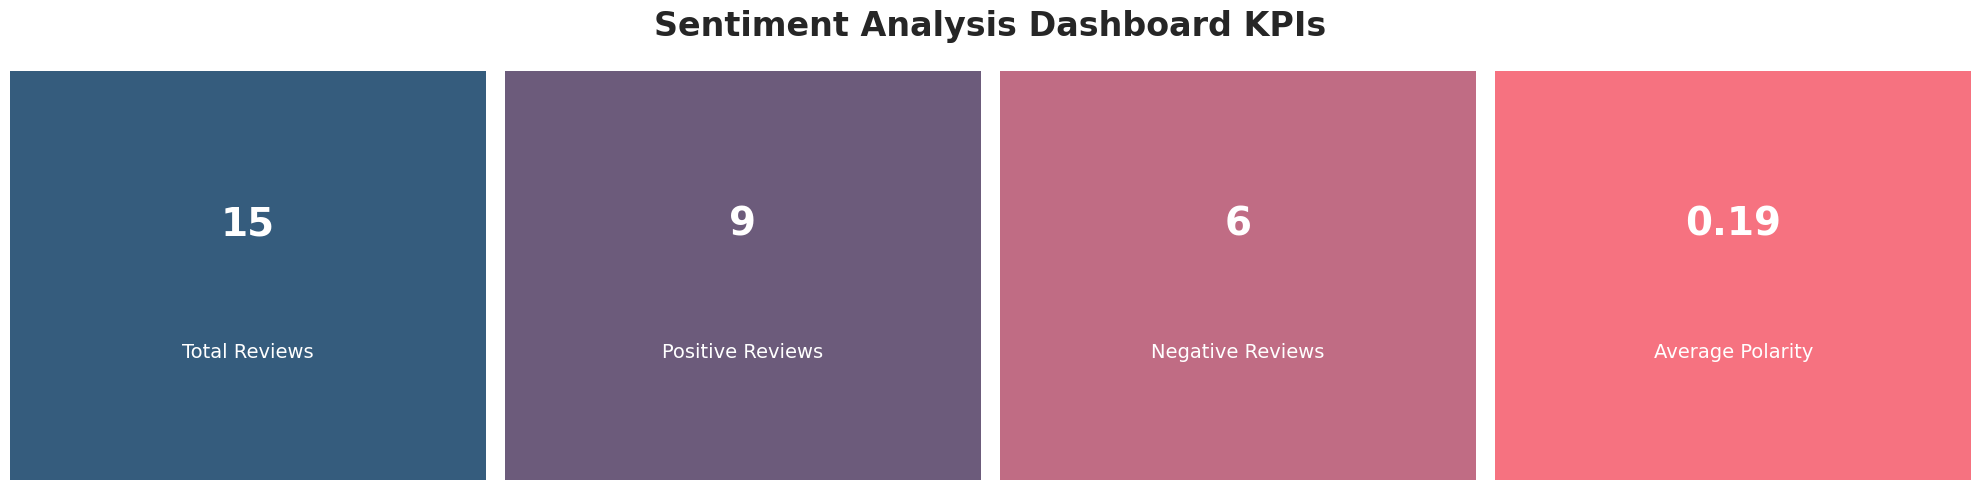

In [25]:


fig, axes = plt.subplots(1, 4, figsize=(20,5))

fig.suptitle(
    "Sentiment Analysis Dashboard KPIs",
    fontsize=24,
    fontweight="bold"
)


total_reviews = len(df)

positive_reviews = (df["Sentiment"] == "Positive").sum()

negative_reviews = (df["Sentiment"] == "Negative").sum()

average_polarity = round(df["Polarity"].mean(), 2)


kpis = [

    ("Total Reviews", total_reviews),

    ("Positive Reviews", positive_reviews),

    ("Negative Reviews", negative_reviews),

    ("Average Polarity", average_polarity)
]


card_colors = ["#355C7D", "#6C5B7B", "#C06C84", "#F67280"]


for ax, (title, value), color in zip(axes, kpis, card_colors):

    ax.set_facecolor(color)

    ax.text(
        0.5,
        0.60,
        str(value),
        fontsize=28,
        color="white",
        fontweight="bold",
        ha='center'
    )

    ax.text(
        0.5,
        0.30,
        title,
        fontsize=14,
        color="white",
        ha='center'
    )

    ax.set_xticks([])

    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    "sentiment_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

/tmp/ipykernel_1839/3874452023.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


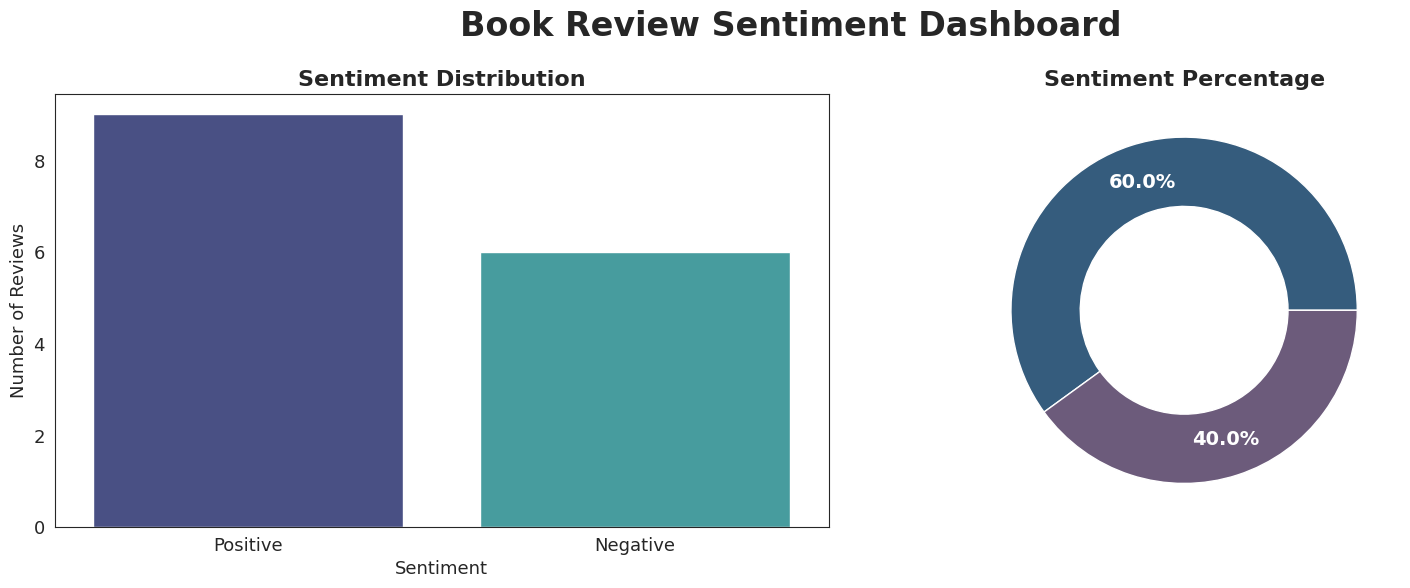

In [24]:


fig, axes = plt.subplots(1, 2, figsize=(16,6))

fig.suptitle(
    "Book Review Sentiment Dashboard",
    fontsize=24,
    fontweight="bold"
)



sns.countplot(
    x="Sentiment",
    data=df,
    ax=axes[0],
    palette="mako"
)

axes[0].set_title(
    "Sentiment Distribution",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_xlabel("Sentiment")

axes[0].set_ylabel("Number of Reviews")



sentiment_counts = df["Sentiment"].value_counts()

custom_colors = ["#355C7D", "#6C5B7B", "#F67280"]

axes[1].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',


    pctdistance=0.78,

    colors=custom_colors,

    wedgeprops={
        'width':0.4,
        'edgecolor':'white'
    },

    textprops={
        'color':'white',
        'fontsize':14,
        'fontweight':'bold'
    }
)

axes[1].set_title(
    "Sentiment Percentage",
    fontsize=16,
    fontweight="bold"
)



plt.tight_layout()
plt.savefig(
    "sentiment_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

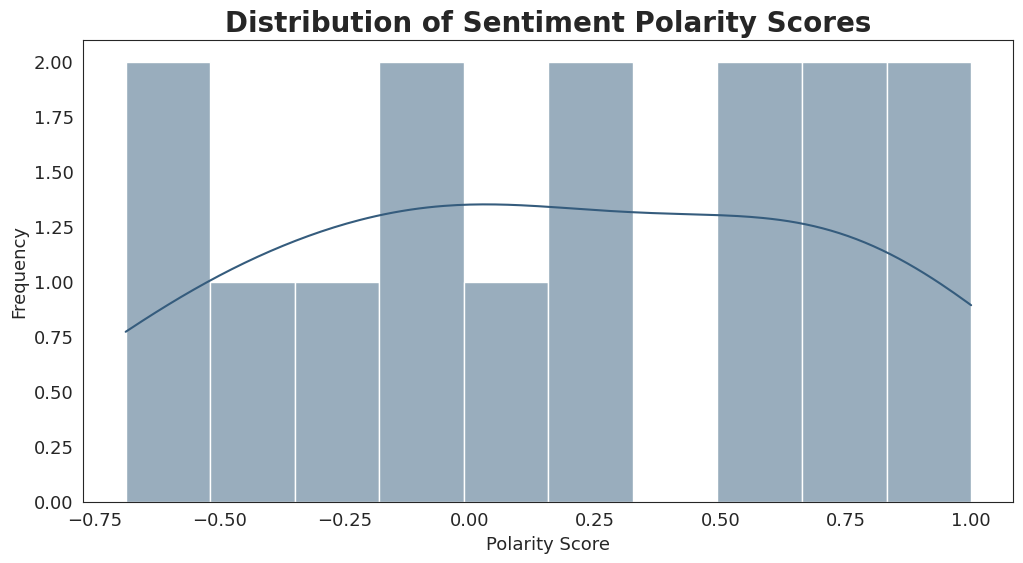

In [22]:


plt.figure(figsize=(12,6))

sns.histplot(
    df["Polarity"],
    bins=10,
    kde=True,
    color="#355C7D"
)

plt.title(
    "Distribution of Sentiment Polarity Scores",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Polarity Score")

plt.ylabel("Frequency")

plt.show()

In [23]:


df.to_excel(
    "sentiment_analysis.xlsx",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [26]:
from google.colab import files

files.download("sentiment_analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>